<a href="https://colab.research.google.com/github/olumayowaadeniyi68-arch/AVCAD-EXERCISE/blob/main/Exercise11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.metrics import pairwise_distances

from sklearn.manifold import MDS

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [22]:
# Load dataset

df = pd.read_csv(
    "EFIplus_medit.csv",
    sep=';'
)

df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [23]:
print(df.columns.tolist())

['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophication', 'Organic_p

In [24]:
# Search for catchment columns

[col for col in df.columns if 'catch' in col.lower()]

['Catchment_name',
 'Elevation_mean_catch',
 'prec_ann_catch',
 'Barriers_catchment_down']

In [25]:
# Check unique catchments

df['Catchment_name'].unique()

array(['Guadalquivir', 'Tejo', 'Douro', 'Segura', 'Jucar', 'Ebro',
       'Cantabrica', 'Guadia', 'Jucar-Ebro', 'Sur', 'Galiza-Norte',
       'Minho', 'Galiza-Sul', 'Catala', 'Segura-Jucar', 'Garonne',
       'Rhone', 'South_France_E', 'South_France_W', 'Corse',
       'Ombrone-Tevere', 'Campania-South', 'Tevere', 'Arno-Ombrone',
       'Italia-Veneto', 'Sardinia', 'Ombrone', 'Saline-Pescara-Sangro',
       'Oeste', 'Mira', 'Mondego', 'Odelouca', 'Algarve-Sotavento',
       'Algarve-barlavento', 'Sado', 'Tejo-Sado', 'Vouga',
       'EntreDouroeVouga', 'Vouga-Mondego'], dtype=object)

In [26]:
# Filter selected catchments

target_catchments = [
    'Douro',
    'Tejo',
    'Mondego',
    'Minho'
]

filtered_df = df[
    df['Catchment_name'].isin(
        target_catchments
    )
]

filtered_df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
5,ES_02_0005,40.732830,-2.078003,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [27]:
print(filtered_df.shape)

(1703, 164)


In [28]:
# Quantitative environmental variables

variables = [
    'Altitude',
    'Actual_river_slope',
    'temp_ann',
    'temp_jan',
    'temp_jul',
    'prec_ann_catch'
]

X = filtered_df[
    variables
].apply(
    pd.to_numeric,
    errors='coerce'
)

X = X.dropna()

X.head()

,Altitude,Actual_river_slope,temp_ann,temp_jan,temp_jul,prec_ann_catch
1,1253,13.406,9.3,0.6,18.9,640.327779
2,1155,9.398,10.1,1.2,19.6,633.238847
3,1074,8.186,10.1,1.2,19.5,625.841858
4,1018,11.736,10.3,1.7,20.0,622.111415
5,979,2.670,10.6,1.8,20.2,608.146170


In [29]:
# Standardize variables

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 2.1257665 , -0.07460296, -1.6547649 , -1.93084724, -0.76604362,
        -1.08262747],
       [ 1.83239263, -0.27587255, -1.2872155 , -1.69761939, -0.46102077,
        -1.10777534],
       [ 1.58991015, -0.33673551, -1.2872155 , -1.69761939, -0.50459546,
        -1.13401603],
       [ 1.42226793, -0.15846529, -1.19532815, -1.50326285, -0.286722  ,
        -1.14724972],
       [ 1.30551711, -0.61373228, -1.05749712, -1.46439154, -0.19957261,
        -1.19679119]])

In [30]:
# PCA model

pca = PCA()

pca_result = pca.fit_transform(
    X_scaled
)

print(
    pca.explained_variance_ratio_
)

[0.58219734 0.24025338 0.13591089 0.0293414  0.01066336 0.00163363]


In [31]:
# PCA dataframe

pca_df = pd.DataFrame(
    pca_result[:, :2],
    columns=['PC1', 'PC2']
)

pca_df['Catchment_name'] = filtered_df.loc[
    X.index,
    'Catchment_name'
].values

pca_df.head()

,PC1,PC2,Catchment_name
0,-3.149718,-1.642557,Tejo
1,-2.519493,-1.701967,Tejo
2,-2.403219,-1.662636,Tejo
3,-2.123833,-1.609361,Tejo
4,-1.831682,-1.778454,Tejo


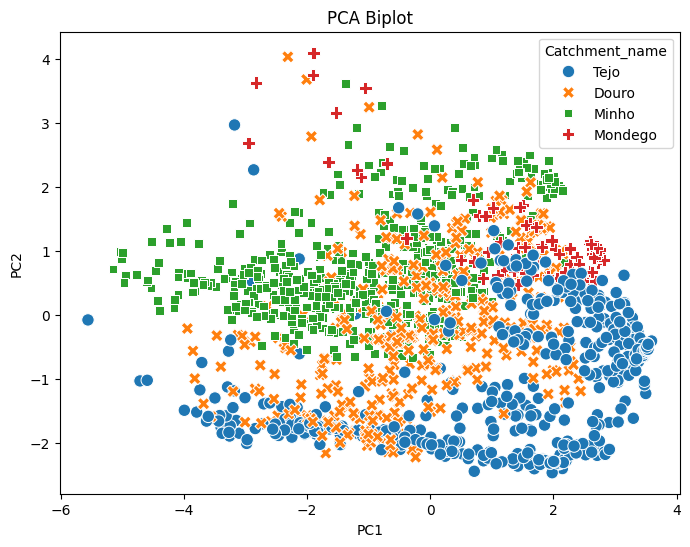

In [32]:
# PCA scatterplot

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Catchment_name',
    style='Catchment_name',
    s=80
)

plt.title("PCA Biplot")

plt.show()

# PCA Interpretation

Principal Component Analysis reduced the environmental variables into principal components.

The PCA biplot visualizes similarities and differences among catchments.

Sites close together are environmentally similar.

In [33]:
# Distance matrix

distance_matrix = pairwise_distances(
    X_scaled,
    metric='euclidean'
)

distance_matrix[:5]

array([[0.        , 0.64010688, 0.78507275, ..., 6.67645651, 6.68177027,
        6.71788467],
       [0.64010688, 0.        , 0.25512621, ..., 6.09232056, 6.10055787,
        6.13803595],
       [0.78507275, 0.25512621, 0.        , ..., 5.9649618 , 5.97247488,
        6.01044274],
       [1.06291058, 0.51004193, 0.39210446, ..., 5.67079506, 5.68040291,
        5.71991433],
       [1.36810159, 0.75841396, 0.60145825, ..., 5.46236606, 5.47421315,
        5.51448271]])

In [34]:
# PCoA / MDS

mds = MDS(
    n_components=2,
    dissimilarity='precomputed',
    random_state=42
)

pcoa_result = mds.fit_transform(
    distance_matrix
)

pcoa_result[:5]

array([[ 1.23101551, -3.34225429],
       [ 1.3643559 , -2.72627106],
       [ 1.33114686, -2.60233277],
       [ 1.30609347, -2.30079824],
       [ 1.52087896, -2.04746388]])

In [35]:
# PCoA dataframe

pcoa_df = pd.DataFrame(
    pcoa_result,
    columns=['Axis1', 'Axis2']
)

pcoa_df['Catchment_name'] = filtered_df.loc[
    X.index,
    'Catchment_name'
].values

pcoa_df.head()

,Axis1,Axis2,Catchment_name
0,1.231016,-3.342254,Tejo
1,1.364356,-2.726271,Tejo
2,1.331147,-2.602333,Tejo
3,1.306093,-2.300798,Tejo
4,1.520879,-2.047464,Tejo


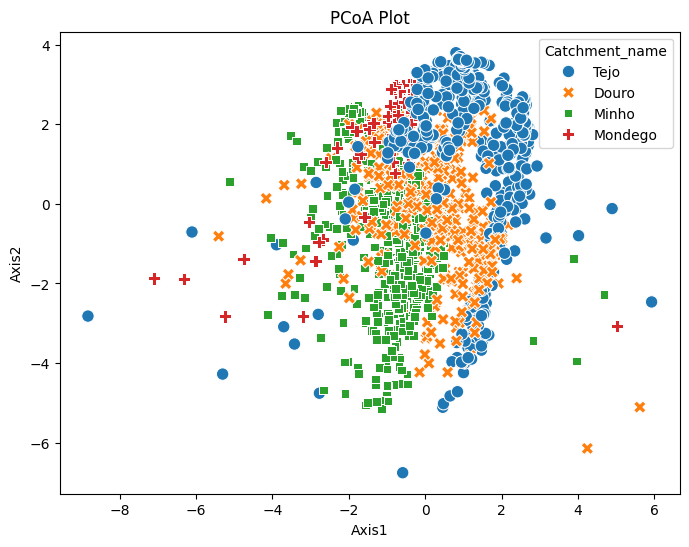

In [36]:
# PCoA scatterplot

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pcoa_df,
    x='Axis1',
    y='Axis2',
    hue='Catchment_name',
    style='Catchment_name',
    s=80
)

plt.title("PCoA Plot")

plt.show()

# PCoA Interpretation

Principal Coordinate Analysis projected the sites into a lower-dimensional space while preserving similarities among observations.

Sites close together are environmentally similar.

In [37]:
# Group labels

groups = filtered_df.loc[
    X.index,
    'Catchment_name'
]

In [38]:
# LDA model

lda = LinearDiscriminantAnalysis()

lda_result = lda.fit_transform(
    X_scaled,
    groups
)

lda_result[:5]

array([[-0.77599695,  1.31906716, -0.7290808 ],
       [-1.23127417,  0.90148237, -1.1155913 ],
       [-0.33522804,  1.19123252, -1.27711556],
       [-0.33454982,  1.70374191, -0.67218843],
       [-0.39748132,  1.49147963, -1.1741363 ]])

In [39]:
# LDA dataframe

lda_df = pd.DataFrame(
    lda_result[:, :2],
    columns=['LD1', 'LD2']
)

lda_df['Catchment_name'] = groups.values

lda_df.head()

,LD1,LD2,Catchment_name
0,-0.775997,1.319067,Tejo
1,-1.231274,0.901482,Tejo
2,-0.335228,1.191233,Tejo
3,-0.334550,1.703742,Tejo
4,-0.397481,1.491480,Tejo


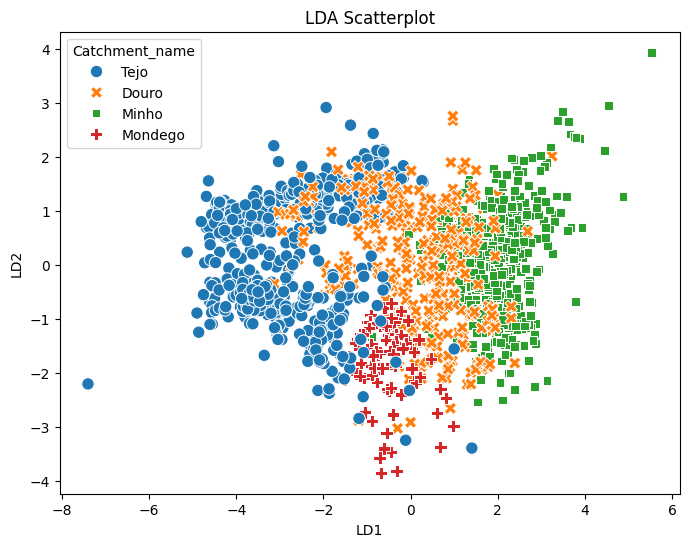

In [40]:
# LDA scatterplot

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=lda_df,
    x='LD1',
    y='LD2',
    hue='Catchment_name',
    style='Catchment_name',
    s=80
)

plt.title("LDA Scatterplot")

plt.show()

# LDA Interpretation

Linear Discriminant Analysis maximized the separation among predefined catchment groups.

The discriminant functions represent combinations of environmental variables that best distinguish the catchments.

# Final Conclusion

This exercise explored:
- Principal Component Analysis (PCA)
- Principal Coordinate Analysis (PCoA)
- Linear Discriminant Analysis (LDA)

Ordination techniques help reduce dimensionality and visualize similarities among environmental observations and catchment groups.